# 01 – Exploratory Data Analysis (EDA)

This notebook performs initial exploration of the selected network intrusion dataset (Wednesday-workingHours.pcap_ISCX.csv).

The purpose of this analysis is to:

- Understand the dataset structure and size  
- Identify feature types and target label  
- Examine class distribution  
- Detect missing values and duplicates  
- Identify basic preprocessing requirements  

This step supports Phase 1 of the project and ensures the dataset is suitable for anomaly detection and classification modeling in Network Sentinel.

### Step 1 : Loading Dataset

In [1]:
import pandas as pd

file_path = "../data/raw/Wednesday-workingHours.pcap_ISCX.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Shape:", df.shape)

Shape: (692703, 79)


### Step 2: Investigating Column names

In [3]:
# Remove leading/trailing spaces from all column names

df.columns = df.columns.str.strip()
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [4]:
# Check Label distribution

df["Label"].value_counts()

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

### Label Distribution Analysis

- The dataset contains both benign and malicious traffic records.
- Benign traffic represents the majority class, while several attack types such as DoS Hulk, GoldenEye, Slowloris, Slowhttptest, and Heartbleed are present.
- The distribution shows class imbalance, particularly with extremely rare attacks such as Heartbleed. This confirms that the dataset is suitable for anomaly detection and multi-class classification modeling.
- Class imbalance will be considered during model development in later phases.

### Step 3: Missing Values

In [5]:
# Check missing values

df.isnull().sum().sum()

np.int64(1008)

In [6]:
# Find columns that contain missing vallues

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Flow Bytes/s    1008
dtype: int64

### Missing Value Analysis

- The dataset contains a small number of missing values (1008) in the feature "Flow Bytes/s".
- Given the total dataset size (over 690,000 records), the proportion of missing values is very small.
- These missing values will be handled during preprocessing in the next phase, either by imputation or removal depending on modeling requirements.

### Step 4: Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(81909)

### Duplicate Record Analysis

- The dataset contains 81,909 duplicate records.
- Duplicate network flow entries are common in intrusion detection datasets due to repeated traffic patterns.
- These duplicates will be removed during preprocessing to ensure model accuracy and prevent bias in training.

### Step 4: Visualization

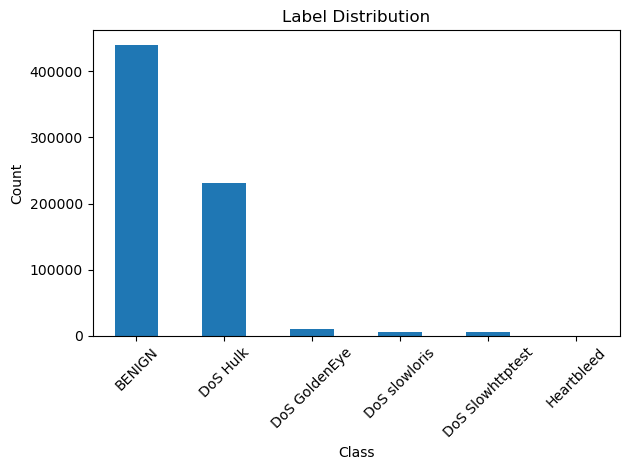

In [12]:
# Label Distribution chart

import matplotlib.pyplot as plt

label_counts = df["Label"].value_counts()

plt.figure()
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

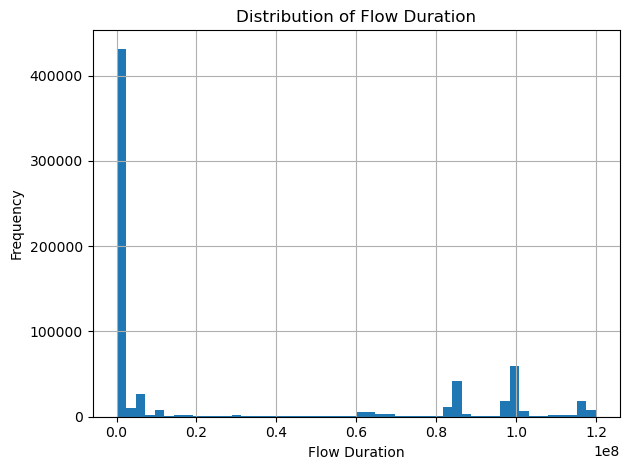

In [13]:
# Flow Duration Distribution

plt.figure()
df["Flow Duration"].hist(bins=50)
plt.title("Distribution of Flow Duration")
plt.xlabel("Flow Duration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Exploratory Data Analysis Summary

- The dataset contains 692,703 records and 79 features representing network traffic flows.
- The target variable includes both benign and multiple attack types, with noticeable class imbalance. Benign traffic forms the majority class, while some attack types such as Heartbleed are extremely rare.
- A small number of missing values were identified in the "Flow Bytes/s" feature. These will be handled during preprocessing.
- The dataset also contains duplicate records, which will be removed to improve model reliability.

Overall, the dataset is suitable for anomaly detection and multi-class classification modeling in the Network Sentinel system.